Практика 22. Часовий ряд: побудова, ковзне середнє, виділення тренду і прогноз
Студент: Войтович Богдан
Група: IT-32
Варіант 6 — Чернігів
base_temp=8.0, amplitude=13, trend_per_year=0.03, noise_scale=0.9

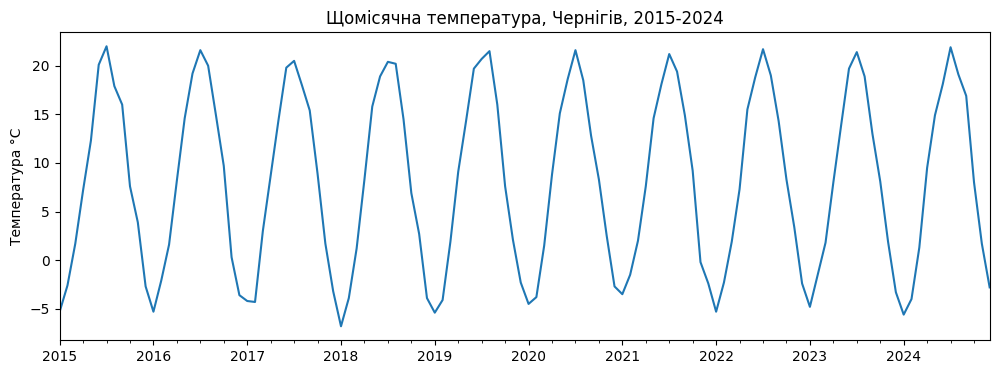

Графік показує сезонні коливання з чітким циклом у 12 місяців і повільний підйом тренду.


In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(6)

base_temp = 8.0
amplitude = 13
trend_per_year = 0.03
noise_scale = 0.9
city = "Чернігів"

n_years = 10
dates = pd.date_range(start="2015-01-01", periods=n_years*12, freq="MS")
month = dates.month
years_elapsed = (dates.year - dates.year[0]) + (dates.month - 1) / 12

seasonal = amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
trend = trend_per_year * years_elapsed
noise = np.random.normal(0, noise_scale, len(dates))

temp = np.round(base_temp + trend + seasonal + noise, 1)
climate_ts = pd.Series(temp, index=dates, name="температура")

climate_ts.plot(title=f"Щомісячна температура, {city}, 2015-2024", figsize=(12,4))
plt.ylabel("Температура °C")
plt.show()

# Короткий опис
print("Графік показує сезонні коливання з чітким циклом у 12 місяців і повільний підйом тренду.")


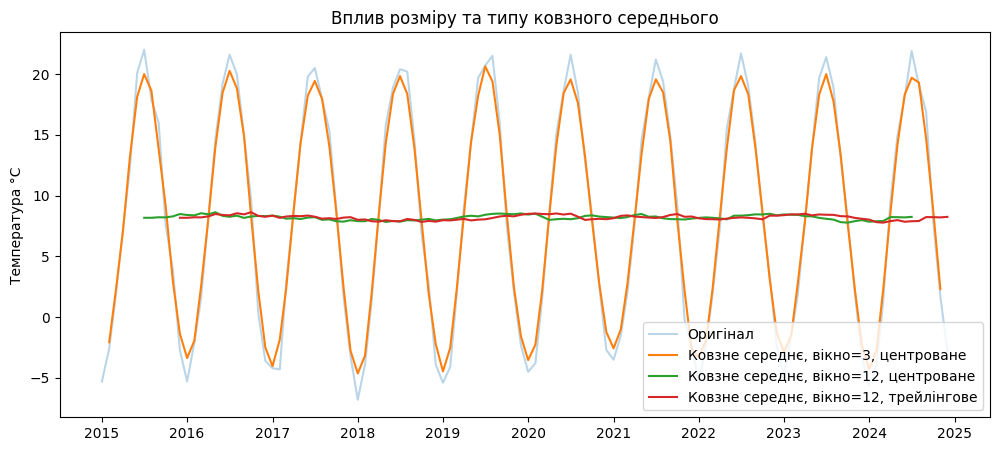

In [102]:
ma3 = climate_ts.rolling(window=3, center=True).mean()
ma12_center = climate_ts.rolling(window=12, center=True).mean()
ma12_trail = climate_ts.rolling(window=12, center=False).mean()

plt.figure(figsize=(12,5))
plt.plot(climate_ts, alpha=0.3, label="Оригінал")
plt.plot(ma3, label="Ковзне середнє, вікно=3, центроване")
plt.plot(ma12_center, label="Ковзне середнє, вікно=12, центроване")
plt.plot(ma12_trail, label="Ковзне середнє, вікно=12, трейлінгове")
plt.legend()
plt.title("Вплив розміру та типу ковзного середнього")
plt.ylabel("Температура °C")
plt.show()

# Пояснення в тексті ноутбука:
# Вікно 12 (один сезон) краще усуває сезонність, лишаючи тренд.
# Центрована версія має менший лаг, трейлінгова зсуває тренд вправо.


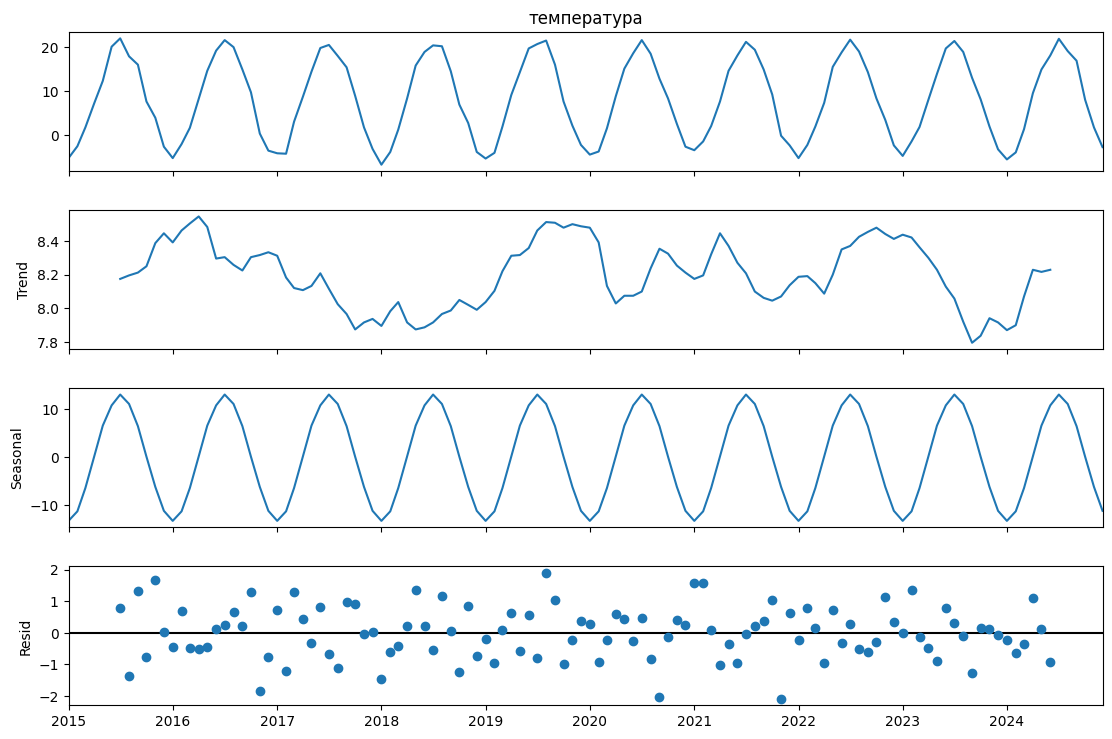

Оцінений тренд (перші 12 місяців):
2015-07-01    8.17
2015-08-01    8.20
2015-09-01    8.21
2015-10-01    8.25
2015-11-01    8.39
2015-12-01    8.45
2016-01-01    8.39
2016-02-01    8.46
2016-03-01    8.50
2016-04-01    8.55
2016-05-01    8.48
2016-06-01    8.30
Freq: MS, Name: trend, dtype: float64

Сезонність (за місяцями):
1    -13.24
2    -11.26
3     -6.41
4      0.17
5      6.58
6     10.79
7     13.04
8     11.08
9      6.47
10     0.11
11    -6.17
12   -11.15
Name: seasonal, dtype: float64


AttributeError: 'float' object has no attribute 'round'

In [103]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(climate_ts, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()

print("Оцінений тренд (перші 12 місяців):")
print(decomp.trend.dropna().head(12).round(2))
print("\nСезонність (за місяцями):")
print(decomp.seasonal.groupby(decomp.seasonal.index.month).mean().round(2))
print("\nСтандартне відхилення залишку:", decomp.resid.dropna().std().round(2))
print(f"Закладений шум σ = {noise_scale}")


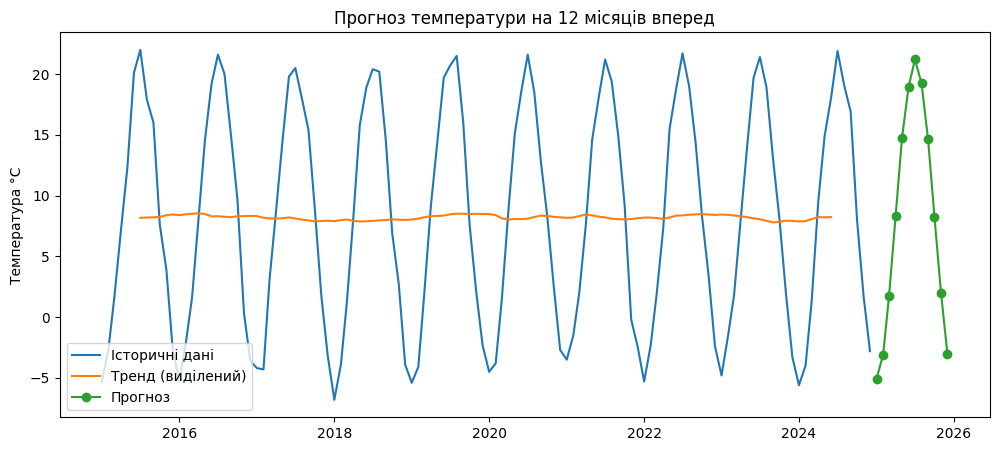

Прогнозовані значення:
 2025-01-01    -5.08
2025-02-01    -3.09
2025-03-01     1.75
2025-04-01     8.33
2025-05-01    14.74
2025-06-01    18.95
2025-07-01    21.20
2025-08-01    19.25
2025-09-01    14.63
2025-10-01     8.27
2025-11-01     1.99
2025-12-01    -2.99
Freq: MS, dtype: float64

Застереження: Прогноз — це екстраполяція лінійного тренду з історичних даних.
Він не враховує можливих різких змін тенденцій або інших факторів.
Точність прогнозу зменшується зі збільшенням горизонту прогнозування.


In [104]:
from scipy.stats import linregress

trend_clean = decomp.trend.dropna()
x = np.arange(len(trend_clean))
fit = linregress(x, trend_clean.values)

n_ahead = 12  # прогноз на рік уперед
x_future = np.arange(len(trend_clean), len(trend_clean) + n_ahead)
trend_forecast = fit.intercept + fit.slope * x_future

seasonal_by_month = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
future_dates = pd.date_range(climate_ts.index[-1] + pd.offsets.MonthBegin(1), periods=n_ahead, freq="MS")
seasonal_forecast = seasonal_by_month.reindex(future_dates.month).values

forecast = pd.Series(trend_forecast + seasonal_forecast, index=future_dates)

plt.figure(figsize=(12,5))
plt.plot(climate_ts, label='Історичні дані')
plt.plot(decomp.trend, label='Тренд (виділений)')
plt.plot(forecast, 'o-', label='Прогноз')
plt.legend()
plt.title(f"Прогноз температури на {n_ahead} місяців вперед")
plt.ylabel("Температура °C")
plt.show()

print("Прогнозовані значення:\n", forecast.round(2))

# Обов'язкове застереження:
print("\nЗастереження: Прогноз — це екстраполяція лінійного тренду з історичних даних.\n"
      "Він не враховує можливих різких змін тенденцій або інших факторів.\n"
      "Точність прогнозу зменшується зі збільшенням горизонту прогнозування.")


In [106]:
print(f"Оцінка нахилу тренду (slope): {fit.slope:.5f} °C/місяць")
print(f"p-value перевірки нахилу = {fit.pvalue:.5e}")

alpha = 0.05
if fit.pvalue < alpha:
    print("Відхиляємо H0: тренд статистично значущий (потепління є).")
else:
    print("Не відхиляємо H0: тренд може бути наслідком шуму.")

stderr = fit.stderr
lower = fit.slope - 1.96*stderr
upper = fit.slope + 1.96*stderr
print(f"95% довірчий інтервал для нахилу тренду: ({lower:.5f}, {upper:.5f}) °C/місяць")

# Порівняння з коротким вікном (останні 2-3 роки)
short_trend_clean = decomp.trend.dropna()[-36:]
x_short = np.arange(len(short_trend_clean))
fit_short = linregress(x_short, short_trend_clean.values)
print(f"\nОцінка нахилу на останніх 3 роках: {fit_short.slope:.5f} °C/місяць з p-value {fit_short.pvalue:.5e}")

# Висновок: короткі періоди більш чутливі до шуму, статистична значущість може падати.


Оцінка нахилу тренду (slope): -0.00063 °C/місяць
p-value перевірки нахилу = 2.92961e-01
Не відхиляємо H0: тренд може бути наслідком шуму.
95% довірчий інтервал для нахилу тренду: (-0.00179, 0.00054) °C/місяць

Оцінка нахилу на останніх 3 роках: -0.00480 °C/місяць з p-value 1.24573e-01


Контрольні питання
Чому часовий ряд не можна аналізувати тими самими методами, що звичайну незалежну вибірку (Лекції 12–16), і що саме в даних порушує ці припущення?
Часові ряди мають авто-кореляцію між послідовними спостереженнями, тобто значення в часі не є незалежними. Це порушує базові припущення класичних статистичних методів, що вимагають незалежності.

Чому надто мале і надто велике вікно ковзного середнього — обидва є проблемою, і як розмір вікна слід узгоджувати з періодом сезонності?
Маленьке вікно не усуває достатньо шуму, велике — згладжує і згублює структуру (сезонність і тренд) та додає лаг. Оптимально вибирати розмір кратним сезонному періоду, щоб ефективно усунути сезонність.

У чому різниця між трейлінговим (center=False) і центрованим (center=True) ковзним середнім, і чому центроване непридатне для реального часу?
Центрований розраховується на основі рівного числа точок зліва і справа від поточного, тому для майбутніх точок потрібні дані, яких у реальному часі нема. Трейлінгове бере лише поточне і попередні значення, тому використовується у онлайн-аналізі.

Чому саме p-value нахилу тренду, а не тільки знак slope, визначає наявність статистично підтвердженого тренду?
Бо позитивний нахил може бути випадковим шумом. p-value показує, наскільки ймовірно отримати такий нахил випадково, якщо насправді тренд відсутній (H0: нахил=0). Статистична значущість визначається цим p-value.